In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
movies=pd.read_csv("../data/movies.csv")
ratings=pd.read_csv("../data/ratings.csv")
print(movies.shape, ratings.shape)

(9742, 3) (100836, 4)


In [2]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

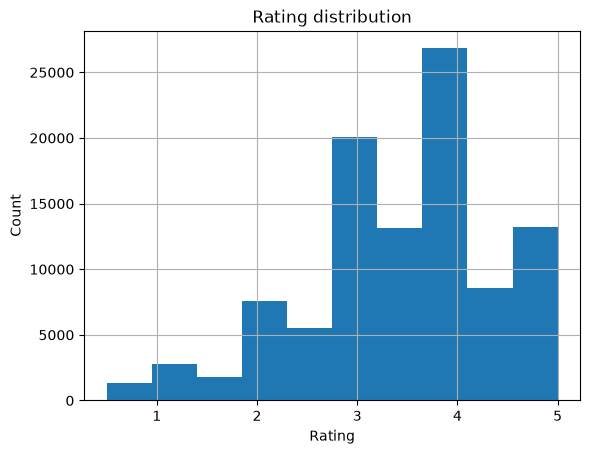

In [6]:
ratings["rating"].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating distribution")
plt.show()


In [7]:
counts = ratings.groupby("movieId").size().reset_index(name="num_ratings")
top = counts.merge(movies, on="movieId")
top.sort_values("num_ratings", ascending=False).head(10)

,movieId,num_ratings,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


In [8]:
avg = ratings.groupby("movieId")["rating"].mean().reset_index(name="avg_rating")
stats = counts.merge(avg, on="movieId").merge(movies, on="movieId")
stats[stats["num_ratings"] >= 50].sort_values("avg_rating", ascending=False).head(10)

,movieId,num_ratings,avg_rating,title,genres
277,318,317,4.429022,"Shawshank Redemption, The (1994)",Crime|Drama
659,858,192,4.289062,"Godfather, The (1972)",Crime|Drama
2224,2959,218,4.272936,Fight Club (1999),Action|Crime|Drama|Thriller
974,1276,57,4.271930,Cool Hand Luke (1967),Drama
602,750,97,4.268041,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
686,904,84,4.261905,Rear Window (1954),Mystery|Thriller
921,1221,129,4.259690,"Godfather: Part II, The (1974)",Crime|Drama
6298,48516,107,4.252336,"Departed, The (2006)",Crime|Drama|Thriller
913,1213,126,4.250000,Goodfellas (1990),Crime|Drama
694,912,100,4.240000,Casablanca (1942),Drama|Romance
